# 27_03 랜덤 포레스트 고장 임박 분류


In [2]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## 모델 만들고 학습시키기
모듈 2에서 만든 X_train, y_train으로 랜덤 포레스트 학습

### 분류기 불러오기
`sklearn.ensemble`에서 `RandomForestClassifier` 임포트

In [3]:
# 코드
pd.set_option("display.max_colwidth", 1000)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import set_config
set_config(display="text")

### 모델 생성
트리 100그루 모델 생성 — 아직 학습 전 빈 상자


In [4]:
# 코드
model = RandomForestClassifier(n_estimators=100, random_state=42)

### 학습 실행
학습용 데이터로 학습 — 평가용은 절대 넣지 않음


In [5]:
# 코

df = pd.read_csv("..\\Data\\27_cmapss_fd001_sample.csv", encoding='utf-8')

df['failure_soon'] = (df['RUL'] <= 30).astype(int)

feats = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']

X = df[feats]
y = df['failure_soon']

X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.2, random_state=42, stratify=y)

### 학습 확인
모델 변수를 출력해 학습이 끝났는지 확인


## 예측하고 결과 형태 확인
- 평가용 데이터로 예측 받고 결과가 0/1 배열임을 확인



In [6]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 예측 실행
예측 결과를 y_pred에 담고 출력 — 0/1로만 이루어진 배열인가?


In [7]:
# 코드
y_pred = model.predict(X_test)

In [8]:
print(y_pred)

[0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0
 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0
 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

### 개수 확인
예측 개수와 평가용 행 개수가 같은지 확인


In [9]:
# 코드
print(len(y_test))
print(len(y_pred))

print(X_test.shape)

723
723
(723, 6)


### 앞부분 보기
예측의 앞 10개만 잘라 보기 — 순서는 X_test와 동일


In [10]:
# 코드
print(y_test.head(10).to_markdown())

print(y_pred[:10])

|      |   failure_soon |
|-----:|---------------:|
| 1431 |              0 |
|  153 |              0 |
|  514 |              0 |
| 2742 |              0 |
| 2522 |              0 |
| 2262 |              0 |
| 1757 |              0 |
| 3167 |              0 |
| 3598 |              1 |
| 1793 |              1 |
[0 0 0 0 0 0 0 0 1 1]


## 결과 형태 정리
- 예측 = 행마다 0/1이 담긴 배열, 입력과 같은 순서
## predict_proba로 확신도 살펴보기
- 각 행의 0일 확률과 1일 확률 확인 — 강한 확신/애매한 행 비교


### 확률 받기
예측 확률을 받아 앞 5개 확인 — 두 확률을 더하면 1이 되는가?


In [11]:
# 코드
proba = model.predict_proba(X_test)
print(proba)

[[1.   0.  ]
 [1.   0.  ]
 [0.86 0.14]
 ...
 [0.99 0.01]
 [1.   0.  ]
 [0.97 0.03]]


In [12]:
proba_2 = model.predict_proba(X_train)
print(proba_2)

[[0.01 0.99]
 [0.09 0.91]
 [1.   0.  ]
 ...
 [0.13 0.87]
 [1.   0.  ]
 [1.   0.  ]]


### 1일 확률만 보기
두 번째 열, 즉 1일 확률(곧 고장 확률)만 따로 보기


In [13]:
# 코드
print(proba[:, 1])

[0.   0.   0.14 0.   0.   0.02 0.   0.21 0.85 0.56 0.48 0.   0.1  0.46
 0.   0.   0.   0.   0.   0.   0.   0.   0.01 0.5  0.   0.39 0.   0.14
 0.   0.87 0.   0.   0.85 0.02 0.   0.01 0.38 0.   0.02 0.   0.9  0.01
 0.   0.   0.98 0.08 0.   0.09 0.   0.61 0.98 0.   0.   0.   0.   0.
 0.65 0.39 0.   0.1  0.03 0.   0.04 0.94 0.   0.   0.01 0.   0.   0.
 0.   0.01 0.   0.   0.   0.   0.   0.   0.   0.87 0.35 0.   0.   0.
 0.   0.   0.   0.   0.31 0.   0.   0.   0.   0.16 0.08 0.   0.62 0.97
 0.   0.   0.6  0.   0.   0.   0.03 0.   0.03 0.   0.79 0.03 0.   0.
 0.   0.34 0.59 0.91 0.04 0.45 0.   0.   0.   0.95 0.   0.62 0.   0.
 0.02 0.   0.64 0.57 0.   0.   0.59 0.98 0.   0.13 0.65 0.   0.04 0.02
 0.01 0.68 0.   0.   0.26 0.01 0.33 0.08 0.   0.   0.66 0.   0.   0.
 0.   0.09 0.   0.31 0.15 0.96 0.03 0.28 0.   0.   0.01 0.   0.   0.45
 0.   0.   0.01 0.   0.11 0.   0.   0.   0.   0.   0.   0.02 0.   0.
 0.05 0.01 0.   0.43 0.2  0.   0.14 0.   0.   0.06 0.5  0.   0.75 0.45
 0.91 0.   0.   0.  

## 확신도 해석
- 확률이 높은 행과 0.5 부근인 행을 비교해 확신도 차이를 느껴 보기
## random_state 바꿔 다시 학습
- 값을 바꾸면 결과가 조금 달라짐, 같은 값이면 똑같이 재현됨


### 다른 random_state로 학습
random_state를 7로 바꿔 새 모델을 학습하고 예측


In [14]:
# 코드
model2 = RandomForestClassifier(n_estimators=100, random_state=7)

In [15]:
model2.fit(X_train, y_train)

RandomForestClassifier(random_state=7)

In [16]:
y_pred2 = model2.predict(X_test)

### 예측 비교
앞 예측과 새 예측의 앞부분 비교 — 일부 예측이 조금 달라졌는가?

In [17]:
# 코드
print(y_pred[:10])
print(y_pred2[:10])

[0 0 0 0 0 0 0 0 1 1]
[0 0 0 0 0 0 0 0 1 1]


### 같은 값이면 재현
같은 random_state 42로 다시 학습해 결과가 똑같은지 확인


In [18]:
# 코드
model3 = RandomForestClassifier(n_estimators=100, random_state=42)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

## 예측 비교 + feature importance
- 예측·실제 눈 비교 + 어떤 센서가 판단에 크게 쓰였는지 확인


In [19]:
proba = model.predict_proba(X_test)[:, 1]
proba2 = model2.predict_proba(X_test)[:, 1]
proba3 = model3.predict_proba(X_test)[:, 1]

### 예측·실제 나란히 보기
예측과 실제를 한 표에 담아 앞부분 확인


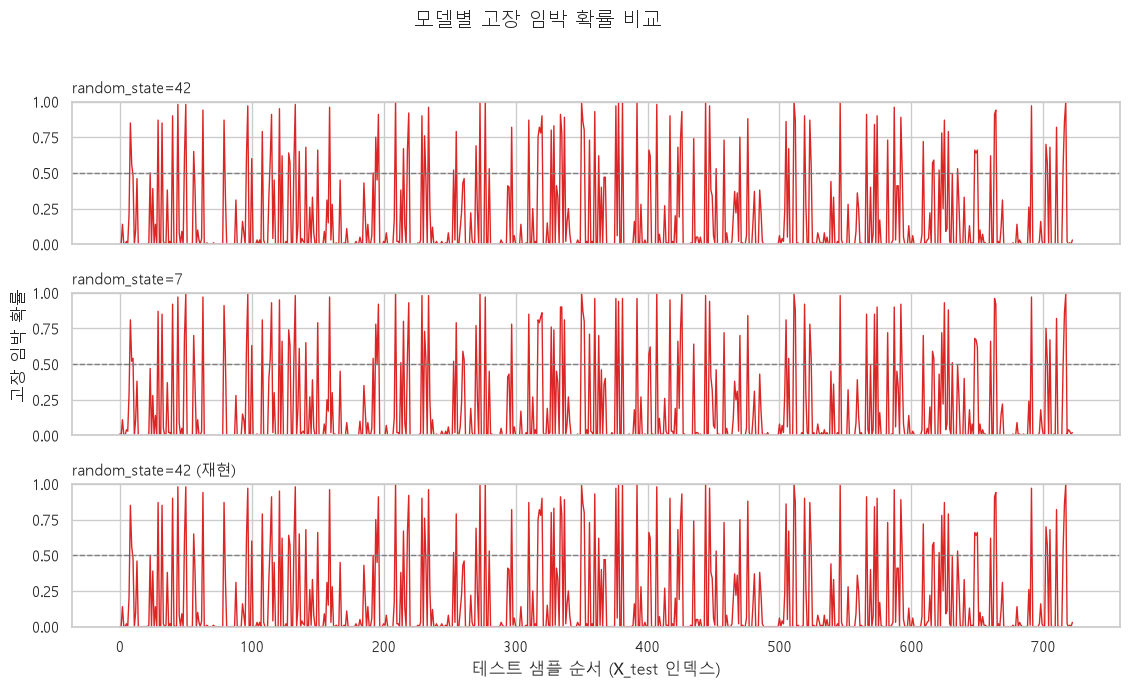

In [20]:
models_probas = [
    (proba, "random_state=42"),
    (proba2, "random_state=7"),
    (proba3, "random_state=42 (재현)"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, sharey=True)

for ax, (p, title) in zip(axes, models_probas):
    ax.plot(p, color="#DC2626", linewidth=1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)  # 판단 경계(0.5) 참고선
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylim(0, 1)

axes[-1].set_xlabel("테스트 샘플 순서 (X_test 인덱스)")
fig.suptitle("모델별 고장 임박 확률 비교")
fig.text(0.06, 0.5, "고장 임박 확률", va="center", rotation="vertical")

plt.tight_layout(rect=[0.07, 0, 1, 0.96])
plt.show()

## 눈으로 일치 세기
- 표를 보며 예측과 실제가 같은 행이 많은지 확인


### 중요 센서 확인
각 센서의 중요도를 큰 순으로 정렬


In [21]:
# 코드
importance = pd.Series(model.feature_importances_, index=feats)
print(importance.sort_values(ascending=False))

sensor_7     0.286797
sensor_15    0.199502
sensor_2     0.167326
sensor_11    0.151536
sensor_4     0.129044
sensor_3     0.065796
dtype: float64


## 중요도 활용
- 중요한 센서 부위를 우선 점검 안내 — 모델 판단이 현장 행동으로
## 예측 결과를 표로 모아 비교
- 예측·실제·곧고장확률을 한 표에 모아 정비 우선순위로 가공


### 결과 표 만들기
예측·실제·곧고장확률을 한 표에 — 확률은 1일 확률 사용


In [22]:
# 코드
result = pd.DataFrame(
    {
        '예측': y_pred, '실제' : y_test.values, '곧고장확률': proba
    }
)

result.head(10)

,예측,실제,곧고장확률
0,0,0,0.00
1,0,0,0.00
2,0,0,0.14
3,0,0,0.00
4,0,0,0.00
5,0,0,0.02
6,0,0,0.00
7,0,0,0.21
8,1,1,0.85
9,1,1,0.56


### 곧 고장만 추리기
1로 예측된 행만 추리기 — 우선 점검 후보


In [23]:
# 코드
result[result['예측'] == 1].head(15)

,예측,실제,곧고장확률
8,1,1,0.85
9,1,1,0.56
29,1,1,0.87
32,1,1,0.85
40,1,1,0.90
44,1,1,0.98
49,1,0,0.61
50,1,1,0.98
56,1,1,0.65
63,1,1,0.94


### 우선순위 정렬
곧 고장 확률 높은 순으로 정렬해 우선순위 만들기


In [24]:
# 코드
result.sort_values('곧고장확률', ascending=False).head(15)

,예측,실제,곧고장확률
511,1,1,1.00
717,1,1,1.00
209,1,1,1.00
277,1,1,1.00
392,1,1,1.00
444,1,1,1.00
378,1,1,0.99
381,1,1,0.99
350,1,1,0.99
546,1,1,0.99


## 표 활용 정리
- 정렬된 표 자체가 정비 우선순위 목록 — 그대로 정비팀 전달 가능
## MIMII feature CSV로 정상/이상 분류
- 소리 특징 데이터에 똑같은 분류 흐름 적용 — 데이터만 바뀔 뿐


### 소리 데이터 불러오기
`rms`, `spectral_centroid`, `zero_crossing_rate`, `label` 컬럼 확인

In [25]:
# 코드
mdf = pd.read_csv("..\\Data\\27_mimii_features_sample.csv", encoding='utf-8')

print(mdf.head(10))
print()
print(mdf.tail(10))
print()
print(mdf.shape)
print()
print(mdf.columns)

      rms  spectral_centroid  zero_crossing_rate  label
0  0.0456            1091.46              0.0809      0
1  0.0453            1747.22              0.0530      0
2  0.0482            1443.32              0.0688      0
3  0.0859            2566.62              0.1627      1
4  0.0504            1816.70              0.0933      0
5  0.0251            2530.12              0.1038      0
6  0.0582            2370.87              0.1291      1
7  0.0281            1700.24              0.0550      0
8  0.0493            1792.57              0.0706      0
9  0.0385            1709.51              0.0710      0

        rms  spectral_centroid  zero_crossing_rate  label
990  0.0604            2002.23              0.1043      0
991  0.0292            2126.09              0.0626      0
992  0.0322            1527.31              0.0803      0
993  0.0580            2187.31              0.1637      1
994  0.0317            2261.54              0.0405      0
995  0.0486            2271.56     

### X/y 나누기
소리 특징 세 개를 입력 mX로, label을 정답 my로 분리


In [26]:
# 코드
mX = mdf[['rms', 'spectral_centroid', 'zero_crossing_rate']]
my = mdf['label']

print(mX.head())
print()
print(my.head())

      rms  spectral_centroid  zero_crossing_rate
0  0.0456            1091.46              0.0809
1  0.0453            1747.22              0.0530
2  0.0482            1443.32              0.0688
3  0.0859            2566.62              0.1627
4  0.0504            1816.70              0.0933

0    0
1    0
2    0
3    1
4    0
Name: label, dtype: int64


### 학습용/평가용 분리
엔진 때와 똑같이 분리 — stratify로 정상/이상 비율 유지


In [27]:
# 코드
mi_model = RandomForestClassifier(n_estimators=100, random_state=42)

mX_train, mX_test, my_train, mt_test = train_test_split(mX, my, test_size=0.2, random_state=42, stratify=my)

### 학습과 예측
랜덤 포레스트로 학습하고 예측 — 코드 흐름이 엔진 때와 거의 동일


In [28]:
# 코드

mi_model.fit(mX_train, my_train)

RandomForestClassifier(random_state=42)

In [29]:
mi_y_pred = mi_model.predict(mX_test)

In [30]:
print(mi_y_pred)

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 1
 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0]


In [31]:
mi_y_pred = mi_model.predict_proba(mX_test)

In [32]:
print(mi_y_pred)

[[0.98 0.02]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.89 0.11]
 [1.   0.  ]
 [0.99 0.01]
 [1.   0.  ]
 [0.   1.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.91 0.09]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.26 0.74]
 [1.   0.  ]
 [1.   0.  ]
 [0.   1.  ]
 [1.   0.  ]
 [0.   1.  ]
 [0.   1.  ]
 [0.9  0.1 ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.97 0.03]
 [1.   0.  ]
 [1.   0.  ]
 [0.99 0.01]
 [1.   0.  ]
 [0.3  0.7 ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.64 0.36]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.03 0.97]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.01 0.99]
 [1.   0.  ]
 [0.   1.  ]
 [0.   1.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.84 0.16]
 [1.   0.  ]
 [0.   1.  ]
 [1.   0.  ]
 [0.18 0.82]
 [1.   0.  ]

## 소리 분류 정리
- 데이터만 바뀌었을 뿐 흐름은 동일 — 분류의 본질은 같음
## 종합 미니 실습 (전체 파이프라인)
- 불러오기 → 라벨 → X/y → 분리 → 학습 → 예측 전 과정을 한 흐름으로


### 불러오기와 라벨
데이터를 불러오고 RUL로 failure_soon 라벨 만들기

In [41]:
# 코드
cdf = pd.read_csv("..\\Data\\27_cmapss_fd001_sample.csv", encoding="utf-8")

cdf['failure_soon'] = (cdf['RUL'] <= 30).astype(int)

cdf.head(10)

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL,failure_soon
0,1,1,641.533,1588.007,1405.656,553.023,46.875,8.405,146,0
1,1,2,641.861,1584.947,1394.917,554.436,47.396,8.403,145,0
2,1,3,642.513,1586.896,1394.908,554.178,46.963,8.436,144,0
3,1,4,641.986,1584.301,1396.013,554.601,47.165,8.384,143,0
4,1,5,641.853,1587.186,1402.331,554.193,47.313,8.487,142,0
5,1,6,641.832,1583.025,1395.299,554.290,47.490,8.397,141,0
6,1,7,641.641,1581.796,1404.132,554.349,47.345,8.375,140,0
7,1,8,642.127,1585.581,1401.591,554.408,47.267,8.429,139,0
8,1,9,642.058,1586.293,1404.121,553.238,47.134,8.384,138,0
9,1,10,641.744,1584.059,1409.360,553.528,47.458,8.336,137,0


### X/y 구성
센서 여섯 개를 X로, failure_soon을 y로 — RUL이 X에 없는지 확인


In [43]:
cfeats = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']
cX = cdf[cfeats]
cy = cdf['failure_soon']

print(cX.head())
print(len(cX))
print()
print(cy.head())
print(len(cy))

   sensor_2  sensor_3  sensor_4  sensor_7  sensor_11  sensor_15
0   641.533  1588.007  1405.656   553.023     46.875      8.405
1   641.861  1584.947  1394.917   554.436     47.396      8.403
2   642.513  1586.896  1394.908   554.178     46.963      8.436
3   641.986  1584.301  1396.013   554.601     47.165      8.384
4   641.853  1587.186  1402.331   554.193     47.313      8.487
3614

0    0
1    0
2    0
3    0
4    0
Name: failure_soon, dtype: int64
3614


In [45]:
# 코드
c_model = RandomForestClassifier(n_estimators=100, random_state=42)

### 데이터 분리
학습용과 평가용으로 나누기 — stratify=y로 비율 유지


In [49]:
# 코드
cX_train, cX_test, cy_train, cy_test = train_test_split(
    cX, cy, test_size=0.2, random_state=42, stratify=cy
)

print(len(cX_train))
print(len(cX_test))

2891
723


### 학습과 예측
랜덤 포레스트로 학습하고 예측 — 여섯 단계를 막힘 없이 이었나?


In [47]:
# 코드
c_model.fit(cX_train, cy_train)

RandomForestClassifier(random_state=42)

In [50]:
cy_pred = c_model.predict(cX_test)
print(cy_pred)

[0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0
 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0
 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [57]:
cy_pred_prob = c_model.predict_proba(cX_test)[:, 1]
print(cy_pred_prob)
print(len(cy_pred_prob))

[0.   0.   0.14 0.   0.   0.02 0.   0.21 0.85 0.56 0.48 0.   0.1  0.46
 0.   0.   0.   0.   0.   0.   0.   0.   0.01 0.5  0.   0.39 0.   0.14
 0.   0.87 0.   0.   0.85 0.02 0.   0.01 0.38 0.   0.02 0.   0.9  0.01
 0.   0.   0.98 0.08 0.   0.09 0.   0.61 0.98 0.   0.   0.   0.   0.
 0.65 0.39 0.   0.1  0.03 0.   0.04 0.94 0.   0.   0.01 0.   0.   0.
 0.   0.01 0.   0.   0.   0.   0.   0.   0.   0.87 0.35 0.   0.   0.
 0.   0.   0.   0.   0.31 0.   0.   0.   0.   0.16 0.08 0.   0.62 0.97
 0.   0.   0.6  0.   0.   0.   0.03 0.   0.03 0.   0.79 0.03 0.   0.
 0.   0.34 0.59 0.91 0.04 0.45 0.   0.   0.   0.95 0.   0.62 0.   0.
 0.02 0.   0.64 0.57 0.   0.   0.59 0.98 0.   0.13 0.65 0.   0.04 0.02
 0.01 0.68 0.   0.   0.26 0.01 0.33 0.08 0.   0.   0.66 0.   0.   0.
 0.   0.09 0.   0.31 0.15 0.96 0.03 0.28 0.   0.   0.01 0.   0.   0.45
 0.   0.   0.01 0.   0.11 0.   0.   0.   0.   0.   0.   0.02 0.   0.
 0.05 0.01 0.   0.43 0.2  0.   0.14 0.   0.   0.06 0.5  0.   0.75 0.45
 0.91 0.   0.   0.  

In [58]:
cmapss_result = pd.DataFrame(
    {
        "예측": cy_pred, 
        "실제": cy_test,
        "고장예측확률" : cy_pred_prob,
    }
)

cmapss_result.head(20)

,예측,실제,고장예측확률
1431,0,0,0.00
153,0,0,0.00
514,0,0,0.14
2742,0,0,0.00
2522,0,0,0.00
2262,0,0,0.02
1757,0,0,0.00
3167,0,0,0.21
3598,1,1,0.85
1793,1,1,0.56


## 종합 완성 점검
- 여섯 단계를 스스로 완성 — 오류가 나면 어느 단계인지 찾아 고치기
## 종합 결과 읽고 정리
- 예측·실제·확신도·중요 센서를 정비 우선순위로 해석하며 마무리


### 결과 표와 눈비교
예측·실제·곧고장확률을 모아 앞부분 눈비교 — 점수는 다음 파트


In [60]:
# 코드
cmapss_result.sort_values("고장예측확률", ascending=False).head(20)

,예측,실제,고장예측확률
348,1,1,1.00
1653,1,1,1.00
2319,1,1,1.00
3218,1,1,1.00
1643,1,1,1.00
539,1,1,1.00
935,1,1,0.99
2649,1,1,0.99
746,1,1,0.99
1654,1,1,0.99


### 우선순위와 중요 센서
곧 고장 확률 순 우선 점검 목록 + 어떤 센서가 크게 쓰였는지 확인


In [61]:
# 코드
c_importance = pd.Series(c_model.feature_importances_, index=feats)
print(c_importance.sort_values(ascending=False))

sensor_7     0.286797
sensor_15    0.199502
sensor_2     0.167326
sensor_11    0.151536
sensor_4     0.129044
sensor_3     0.065796
dtype: float64



## 한 문장으로 정리
곧 고장 확률 높은 설비부터 점검, 중요 센서 부위 우선 살피기, 사람이 검토